**This cell imports pandas, numpy, scipy.stats and matplotlib, brings in the GARCH helper from src/garch_methods.py, and loads the two portfolio return series from notebook 01. I also rescale the returns by x100 to put them on a percentage scale, because the arch library that powers the GARCH fits is numerically more stable when returns are expressed in percent rather than as fractions like 0.01.**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats             # for the standard-normal quantile (z-score) and PDF used in Vae/ES conversion

from src.config import PROCESSED_DATA_DIR
from src.data_utils import read_panel
from src.garch_methods import garch_forecasts       # walk-forward GARCH or GJR-GARCH variance forecasts

us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.parquet")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.parquet")["return"]

# as mentioned, arch's optimizer converges better on percentage-scale data
us_pct = us * 100
india_pct = india * 100

**This cell runs the walk-forward forecasting loop for both markets and both models.**
 
**Both use a 500-day initial training window and refit every 21 days (about one trading month).**

In [2]:
print("Computing US GARCH...")
us_garch = garch_forecasts(us_pct, asymmetric = False)      # vanilla GARCH(1,1) in the US market
print(f" Done: {len(us_garch)} forecasts")

print("Computing US GJR-GARCH...")
us_gjr = garch_forecasts(us_pct, asymmetric = True)         # GJR-GARCH in the US market adds leverage effect
print(f"Done {len(us_gjr)} forecasts")

print("Computing India GARCH...")
india_garch = garch_forecasts(india_pct, asymmetric = False)         # vanilla GARCH(1,1) in the India market
print(f" Done: {len(india_garch)} forecasts")

print("Computing India GJR-GARCH...")
india_gjr = garch_forecasts(india_pct, asymmetric = True)            # GJR-GARCH in the India market adds leverage effect
print(f"Done {len(india_gjr)} forecasts")

Computing US GARCH...
 Done: 3523 forecasts
Computing US GJR-GARCH...
Done 3523 forecasts
Computing India GARCH...
 Done: 3449 forecasts
Computing India GJR-GARCH...
Done 3449 forecasts


**This cell takes the one-step-ahead volatility forecast from each fitted model and converts it into a VaR and ES number at both confidence levels. The conversion assumes Normal innovations.**

In [3]:
# Standard-normal quantiles for the lower 5% and 1% tails
z_95 = stats.norm.ppf(0.05)
z_99 = stats.norm.ppf(0.01)

# US GARCH: VaR is -sigma*z (positive loss) , ES under Normal innovations is sigma * phi(z) / alpha
us_garch_var_95 = -us_garch["forecast_vol"] * z_95 / 100       # The /100 at the end just undoes the percentage rescaling so outputs are back on fractional return scale
us_garch_es_95 = us_garch["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
us_garch_var_99 = -us_garch["forecast_vol"] * z_99 / 100
us_garch_es_99 = us_garch["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

# US GJR-GARCH: Same conversion formulas bt just applied to asymmetric model's volatility forecast
us_gjr_var_95 = -us_gjr["forecast_vol"] * z_95 / 100
us_gjr_es_95 = us_gjr["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
us_gjr_var_99 = -us_gjr["forecast_vol"] * z_99 / 100
us_gjr_es_99 = us_gjr["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

# India GARCH
india_garch_var_95 = -india_garch["forecast_vol"] * z_95 / 100
india_garch_es_95 = india_garch["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
india_garch_var_99 = -india_garch["forecast_vol"] * z_99 / 100
india_garch_es_99 = india_garch["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

#India GJR-GARCH
india_gjr_var_95 = -india_gjr["forecast_vol"] * z_95 / 100
india_gjr_es_95 = india_gjr["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
india_gjr_var_99 = -india_gjr["forecast_vol"] * z_99 / 100
india_gjr_es_99 = india_gjr["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

print("Converted GARCH variance to VaR/ES.")

Converted GARCH variance to VaR/ES.


**This cell plots the one-step-ahead conditional volatility forecast from both the GARCH and GJR-GARCH models for the US portfolio on the same axes.This is done to observe how the asymmetric term in GJR-GARCH actually changes the volatility path in practice.**

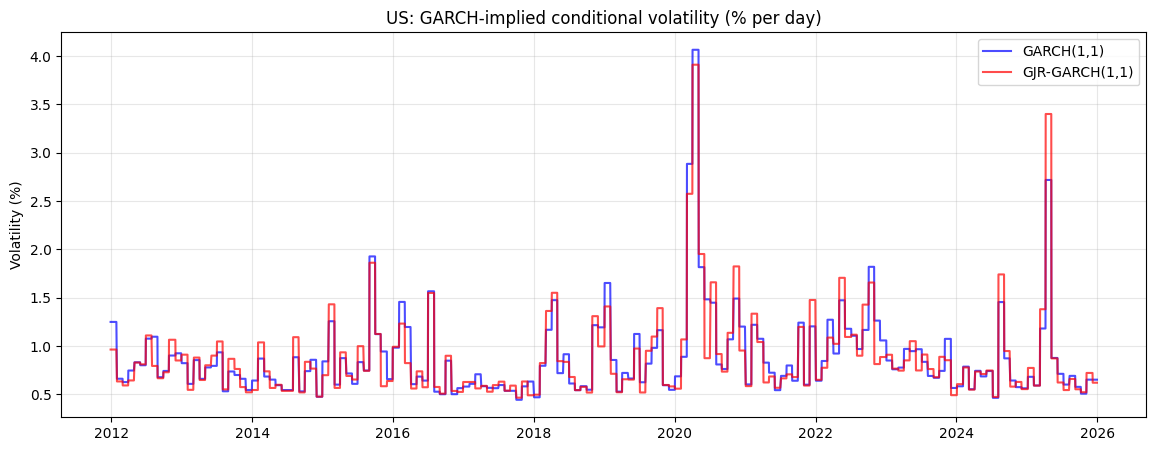

In [4]:
plt.figure(figsize = (14, 5))
plt.plot(us_garch.index, us_garch["forecast_vol"], label = "GARCH(1,1)", color = "blue", alpha = 0.7)
plt.plot(us_gjr.index, us_gjr["forecast_vol"], label = "GJR-GARCH(1,1)", color = "red", alpha = 0.7)
plt.title("US: GARCH-implied conditional volatility (% per day)")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Findings:**

- The two lines are very close most of the time but separate during selloffs. After a large negative return the red GJR-GARCH line jumps above the blue GARCH line because the leverage term loads extra variance onto downside shocks.
- Both lines show clear regimes: long quiet periods around 0.5–1% per day with by sharp spikes during crises. This volatility clustering is what GARCH was designed to capture, and it is why I expect GARCH to outperform the static methods during sustained crises.

**This cell does the same plot for the India portfolio. Comparing the two volatility series side-by-side lets me spot whether the leverage effect is similar across the two markets or not.**

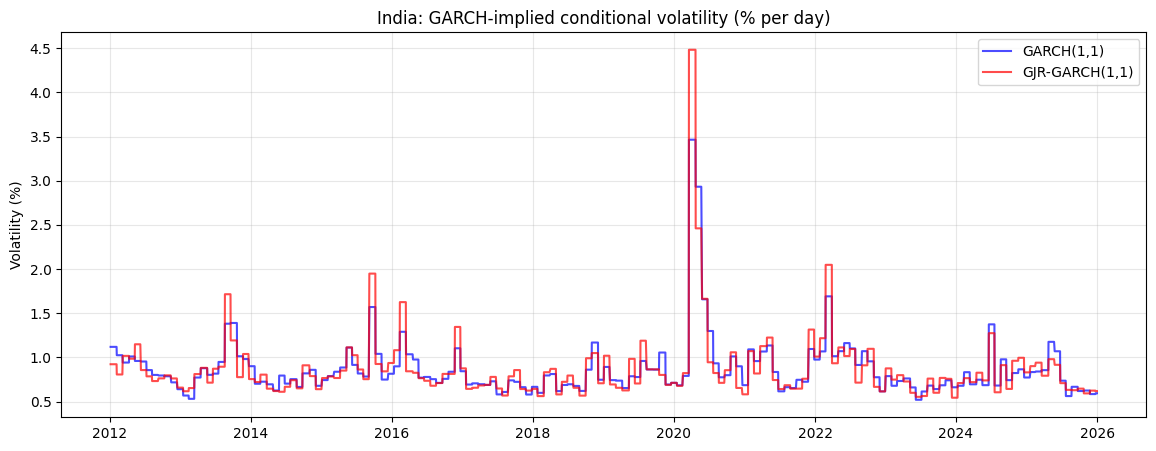

In [5]:
plt.figure(figsize = (14, 5))
plt.plot(india_garch.index, india_garch["forecast_vol"], label = "GARCH(1,1)", color = "blue", alpha = 0.7)
plt.plot(india_gjr.index, india_gjr["forecast_vol"], label = "GJR-GARCH(1,1)", color = "red", alpha = 0.7)
plt.title("India: GARCH-implied conditional volatility (% per day)")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Findings:**
- The India volatility series shows a similar clustering pattern to the US but the gap between the GARCH and GJR-GARCH lines is smaller than on the US chart, showing that the leverage effect is weaker in this India portfolio.

**This cell overlays the GARCH and GJR-GARCH 95% VaR thresholds on the US daily return series. The point of plotting it is to see how dynamically the threshold reacts to changes in the volatility regime.**

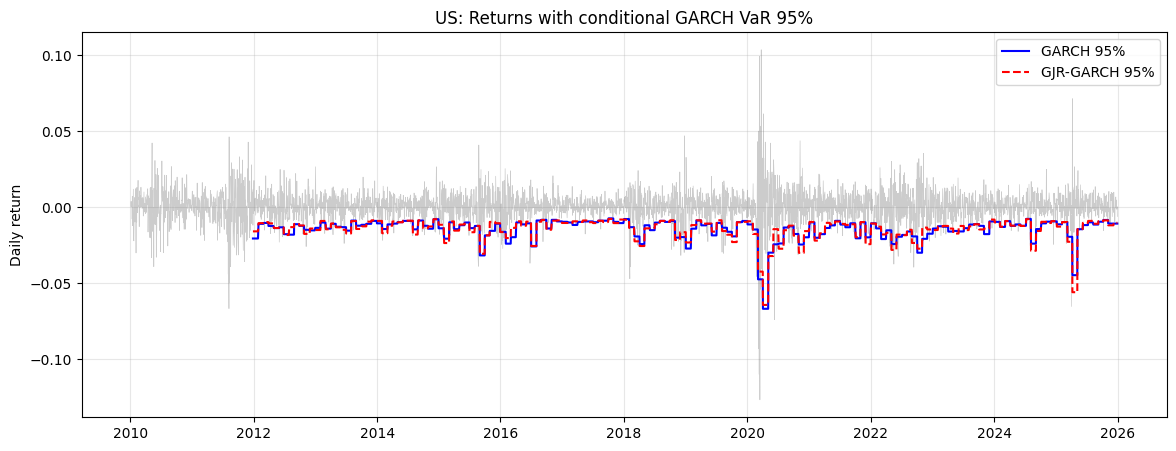

In [6]:
plt.figure(figsize = (14, 5))
plt.plot(us.index, us, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(us_garch_var_95.index, -us_garch_var_95, color = "blue", label = "GARCH 95%")
plt.plot(us_gjr_var_95.index, -us_gjr_var_95, linestyle = "--", color = "red", label = "GJR-GARCH 95%")
plt.title("US: Returns with conditional GARCH VaR 95%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Findings:**

- The GARCH thresholds widen sharply as soon as a high-volatility regime begins, whereas the static rolling-window thresholds in notebook 2 only start widening after a year of high-volatility data accumulates in the window. This is the core advantage of conditional volatility models like GARCH, which respond to changes in volatility regimes immediately rather than with a rolling-window lag.

**This cell repeats the US plot at the 99% level. I want to see whether the same adaptive behaviour holds further out in the tail.**

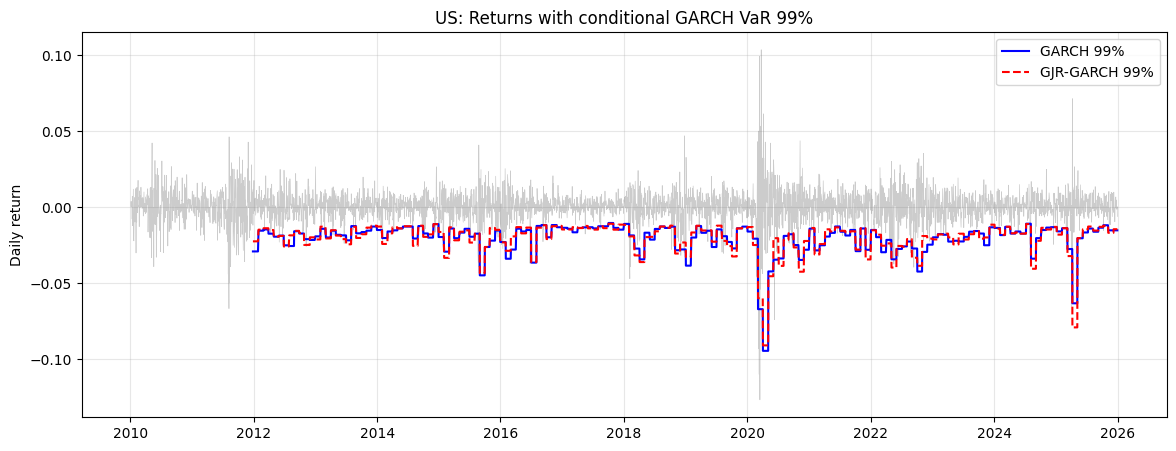

In [7]:
plt.figure(figsize = (14, 5))
plt.plot(us.index, us, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(us_garch_var_99.index, -us_garch_var_99, color = "blue", label = "GARCH 99%")
plt.plot(us_gjr_var_99.index, -us_gjr_var_99, linestyle = "--", color = "red", label = "GJR-GARCH 99%")
plt.title("US: Returns with conditional GARCH VaR 99%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**This cell does the same 95% return-and-threshold overlay for the India portfolio. I want to compare visually whether the GARCH threshold tracks volatility regimes as well in India as it does in the US.**

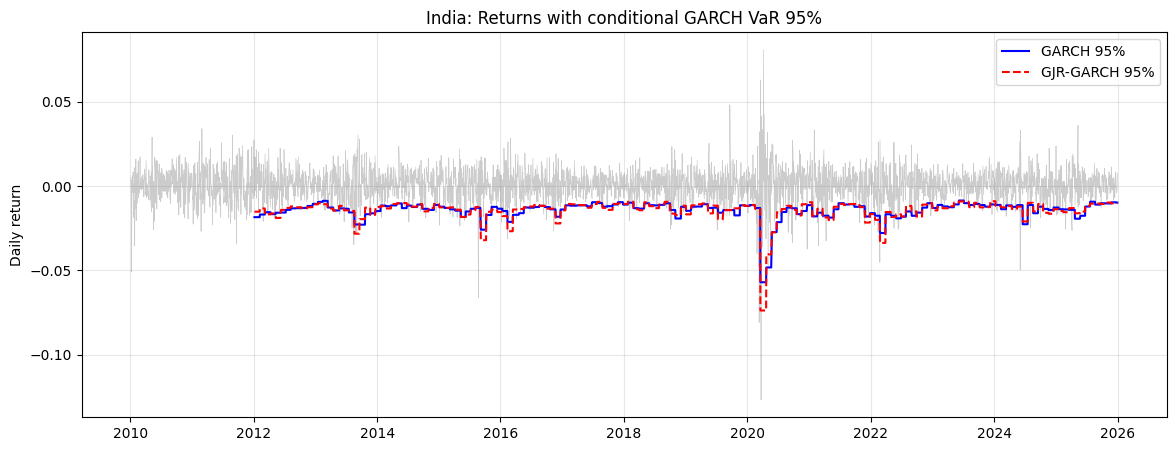

In [8]:
plt.figure(figsize = (14, 5))
plt.plot(india.index, india, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(india_garch_var_95.index, -india_garch_var_95, color = "blue", label = "GARCH 95%")
plt.plot(india_gjr_var_95.index, -india_gjr_var_95, linestyle = "--", color = "red", label = "GJR-GARCH 95%")
plt.title("India: Returns with conditional GARCH VaR 95%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Findings:**

- The GARCH and GJR-GARCH thresholds for India track each other more tightly than they did for the US due to the weaker leverage effect in this India portfolio. 

**This cell repeats the India overlay at the 99% level.**

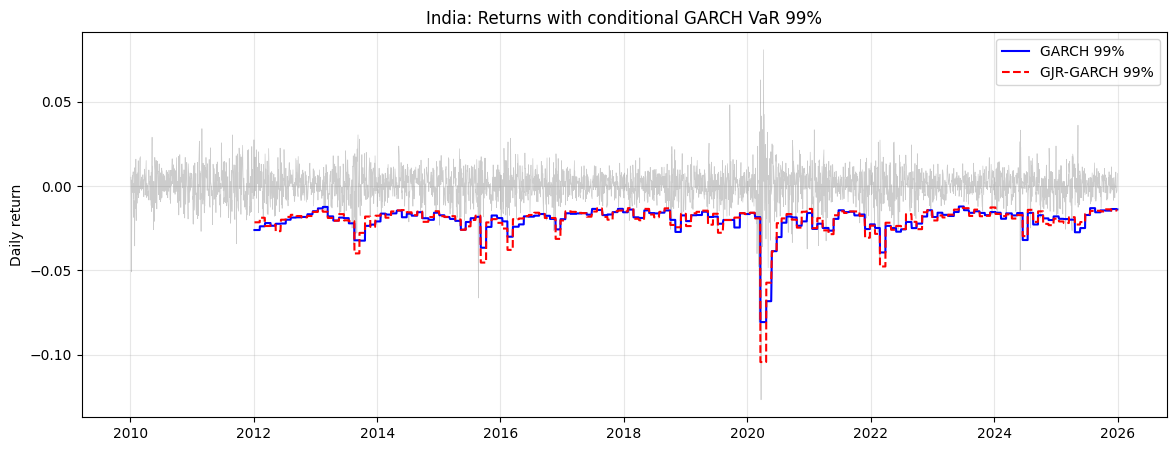

In [9]:
plt.figure(figsize = (14, 5))
plt.plot(india.index, india, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(india_garch_var_99.index, -india_garch_var_99, color = "blue", label = "GARCH 99%")
plt.plot(india_gjr_var_99.index, -india_gjr_var_99, linestyle = "--", color = "red", label = "GJR-GARCH 99%")
plt.title("India: Returns with conditional GARCH VaR 99%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**This cell writes the raw GARCH forecast objects and all eight VaR/ES series to data/processed/. Notebooks 04, 05, and 06 all read from these files.**

In [10]:
us_garch.to_parquet(PROCESSED_DATA_DIR / "us_garch_forecasts.parquet")
us_gjr.to_parquet(PROCESSED_DATA_DIR / "us_gjr_forecasts.parquet")
india_garch.to_parquet(PROCESSED_DATA_DIR / "india_garch_forecasts.parquet")
india_gjr.to_parquet(PROCESSED_DATA_DIR / "india_gjr_forecasts.parquet")

pd.DataFrame({"var": us_garch_var_95, "es": us_garch_es_95}).to_parquet(PROCESSED_DATA_DIR / "us_garch_var_95.parquet")
pd.DataFrame({"var": us_garch_var_99, "es": us_garch_es_99}).to_parquet(PROCESSED_DATA_DIR/ "us_garch_var_99.parquet")
pd.DataFrame({"var": us_gjr_var_95, "es": us_gjr_es_95}).to_parquet(PROCESSED_DATA_DIR / "us_gjr_var_95.parquet")
pd.DataFrame({"var": us_gjr_var_99, "es": us_gjr_es_99}).to_parquet(PROCESSED_DATA_DIR / "us_gjr_var_99.parquet")
pd.DataFrame({"var": india_garch_var_95, "es": india_garch_es_95}).to_parquet(PROCESSED_DATA_DIR / "india_garch_var_95.parquet")
pd.DataFrame({"var": india_garch_var_99, "es": india_garch_es_99}).to_parquet(PROCESSED_DATA_DIR / "india_garch_var_99.parquet")
pd.DataFrame({"var": india_gjr_var_95, "es": india_gjr_es_95}).to_parquet(PROCESSED_DATA_DIR / "india_gjr_var_95.parquet")
pd.DataFrame({"var": india_gjr_var_99, "es": india_gjr_es_99}).to_parquet(PROCESSED_DATA_DIR / "india_gjr_var_99.parquet")

print("Saved.")

Saved.
